<a href="https://colab.research.google.com/github/SEN-ANURAN/Flood_Prediction_Analytics/blob/main/Minor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import rasterio
import rasterio.transform
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from pyproj import Transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
before = rasterio.open('/content/Before_Flood (1).tif')
after  = rasterio.open('/content/After_Flood (1).tif')

band_count = before.count
print(f"Band count in TIF: {band_count}")
print(f"CRS: {before.crs}")

if band_count >= 5:
    b2_before, b3_before, b4_before, b8_before, b11_before = before.read()[:5]
    b2_after,  b3_after,  b4_after,  b8_after,  b11_after  = after.read()[:5]
    HAS_SWIR = True
    print("B11 (SWIR1) loaded — real NDBI will be computed.")
else:
    b2_before, b3_before, b4_before, b8_before = before.read()
    b2_after,  b3_after,  b4_after,  b8_after  = after.read()
    b11_before = b11_after = None
    HAS_SWIR = False
    print("WARNING: B11 not found. NDBI will use B4/B8 approximation.")
    print("         To fix: re-export your TIF from GEE including B11.")

print("Before shape:", b2_before.shape)
print("After shape:",  b2_after.shape)


Band count in TIF: 4
CRS: EPSG:32645
         To fix: re-export your TIF from GEE including B11.
Before shape: (439, 464)
After shape: (439, 464)


In [ ]:
def safe_index(a, b):
    return (a - b) / (a + b + 1e-6)

ndvi_before = safe_index(b8_before, b4_before)
ndvi_after  = safe_index(b8_after,  b4_after)
ndwi_before = safe_index(b3_before, b8_before)
ndwi_after  = safe_index(b3_after,  b8_after)

if HAS_SWIR:
    ndbi_before = safe_index(b11_before, b8_before)
    ndbi_after  = safe_index(b11_after,  b8_after)
    print("\nNDBI computed using B11 (SWIR1).")
else:
    ndbi_before = safe_index(b4_before, b8_before)
    ndbi_after  = safe_index(b4_after,  b8_after)
    print("\nNDBI approximated using B4/B8 (Red/NIR).")

water_change = ndwi_after  - ndwi_before
veg_loss     = ndvi_before - ndvi_after



NDBI approximated using B4/B8 (Red/NIR).


In [ ]:
water_change = ndwi_after - ndwi_before
veg_loss     = ndvi_before - ndvi_after

pixel_area = 10 * 10
total_pixels = water_change.size

flood_mask = water_change > 0.05
flood_pixels = np.sum(flood_mask)

veg_loss_mask = veg_loss > 0.10
veg_loss_pixels = np.sum(veg_loss_mask)

flood_area_km2 = flood_pixels * pixel_area / 1e6
veg_loss_km2 = veg_loss_pixels * pixel_area / 1e6

print("\nFlood Impact Summary")
print("Total Area km²:", total_pixels * pixel_area / 1e6)
print("Flood Area km²:", flood_area_km2)
print("Vegetation Loss km²:", veg_loss_km2)


Flood Impact Summary
Total Area km²: 20.3696
Flood Area km²: 1.3761
Vegetation Loss km²: 1.753


In [ ]:
def latlon_ticks(ax, src_crs, transform, shape, n=5):
    h, w = shape
    xticks = np.linspace(0, w - 1, n).astype(int)
    yticks = np.linspace(0, h - 1, n).astype(int)
    xlons_native = [rasterio.transform.xy(transform, 0, x)[0] for x in xticks]
    ylats_native = [rasterio.transform.xy(transform, y, 0)[1] for y in yticks]
    t = Transformer.from_crs(src_crs, "EPSG:4326", always_xy=True)
    xlons_deg = [t.transform(x, ylats_native[0])[0] for x in xlons_native]
    ylats_deg = [t.transform(xlons_native[0], y)[1] for y in ylats_native]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{v:.4f}°E" for v in xlons_deg],
                       fontsize=7, rotation=30, ha='right')
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{v:.4f}°N" for v in ylats_deg], fontsize=7)


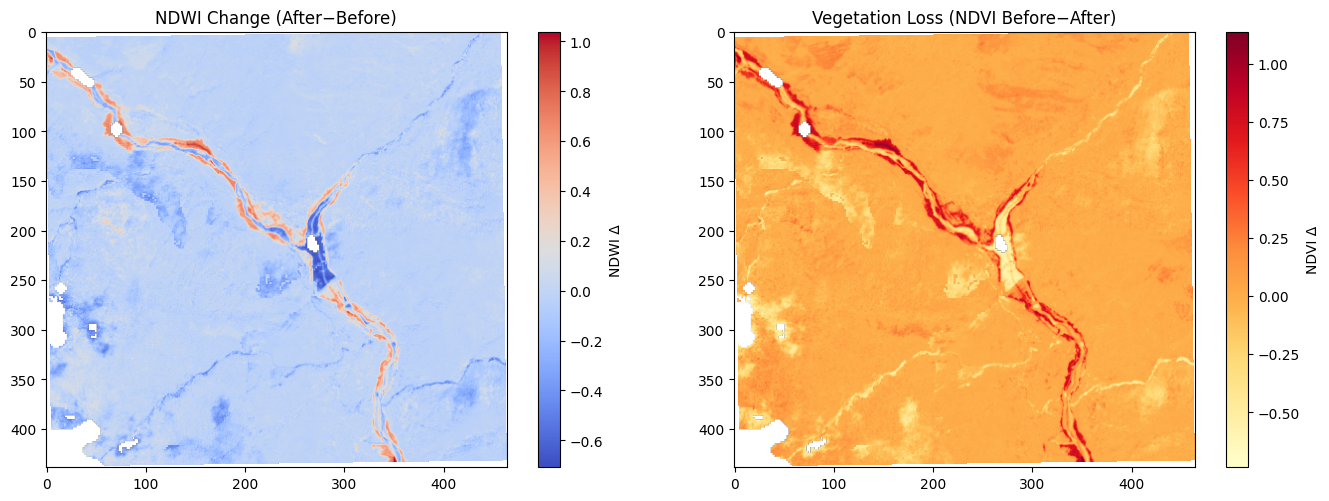

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(water_change, cmap='coolwarm'); axes[0].set_title("NDWI Change (After−Before)"); plt.colorbar(axes[0].images[0], ax=axes[0], label='NDWI Δ')
axes[1].imshow(veg_loss,     cmap='YlOrRd');  axes[1].set_title("Vegetation Loss (NDVI Before−After)"); plt.colorbar(axes[1].images[0], ax=axes[1], label='NDVI Δ')
plt.tight_layout(); plt.show()




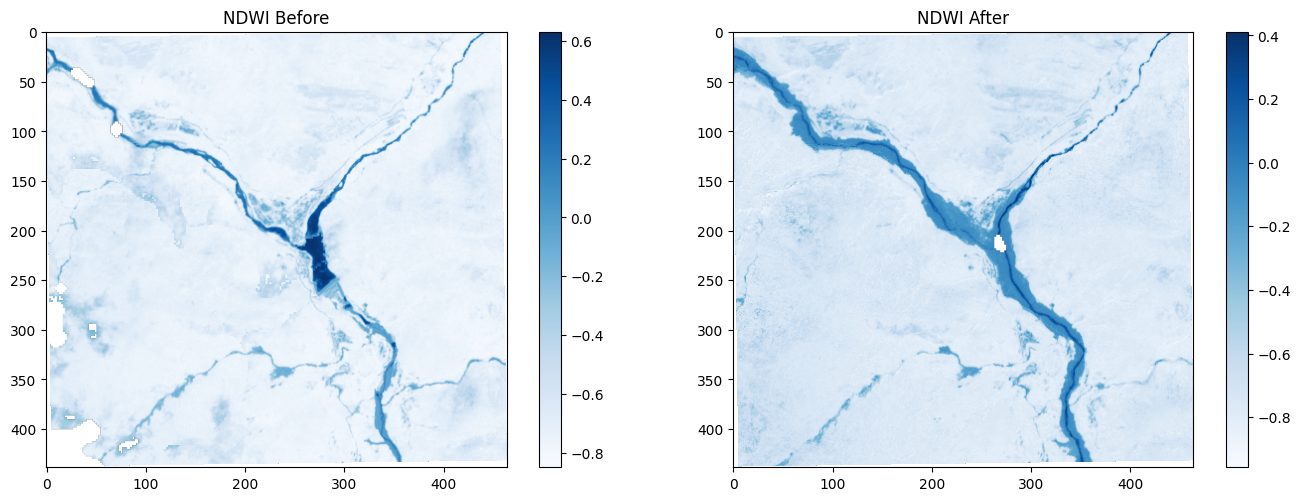

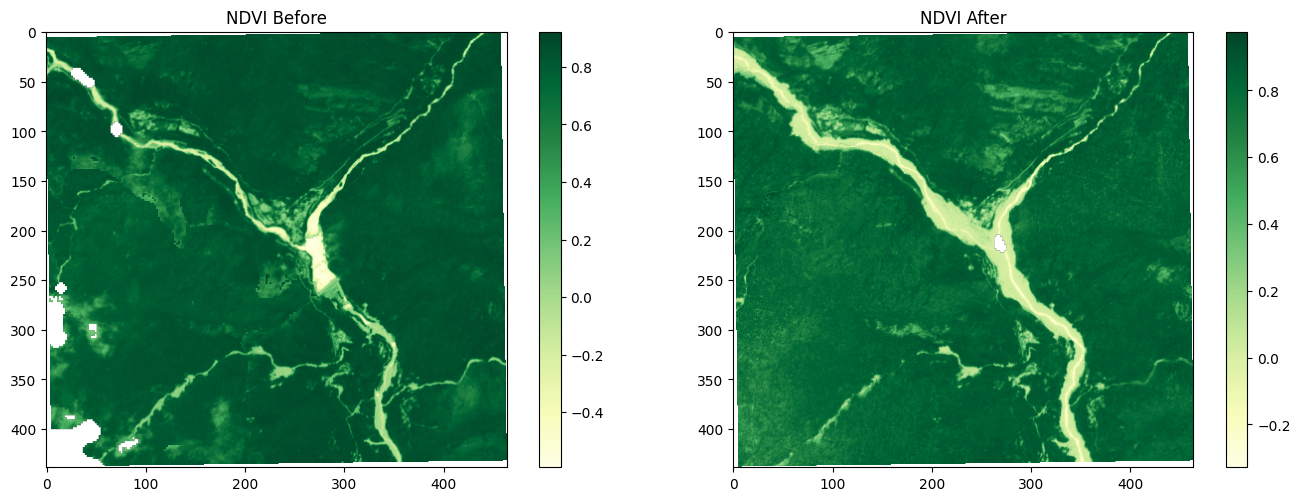

In [ ]:
for title, before_img, after_img, cmap in [
    ("NDWI", ndwi_before, ndwi_after, 'Blues'),
    ("NDVI", ndvi_before, ndvi_after, 'YlGn'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(before_img, cmap=cmap); axes[0].set_title(f"{title} Before"); plt.colorbar(axes[0].images[0], ax=axes[0])
    axes[1].imshow(after_img,  cmap=cmap); axes[1].set_title(f"{title} After");  plt.colorbar(axes[1].images[0], ax=axes[1])
    plt.tight_layout(); plt.show()

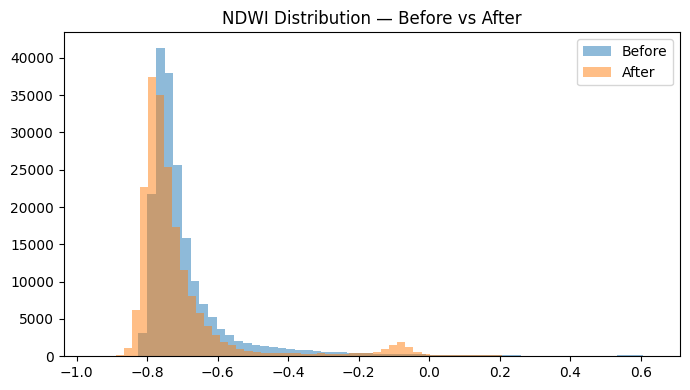

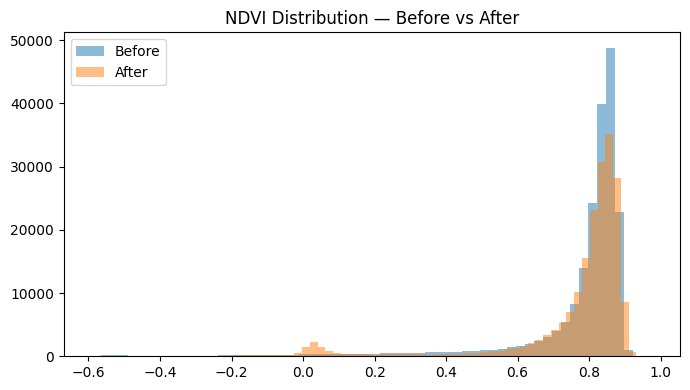

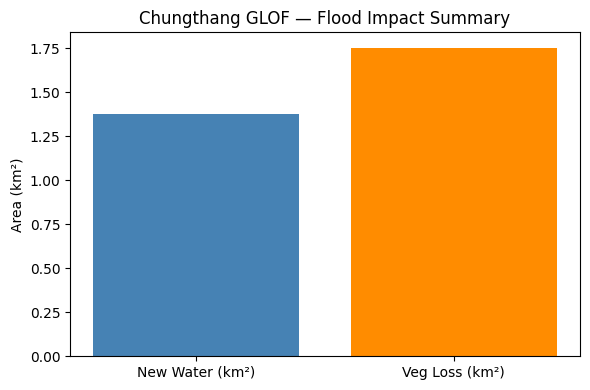

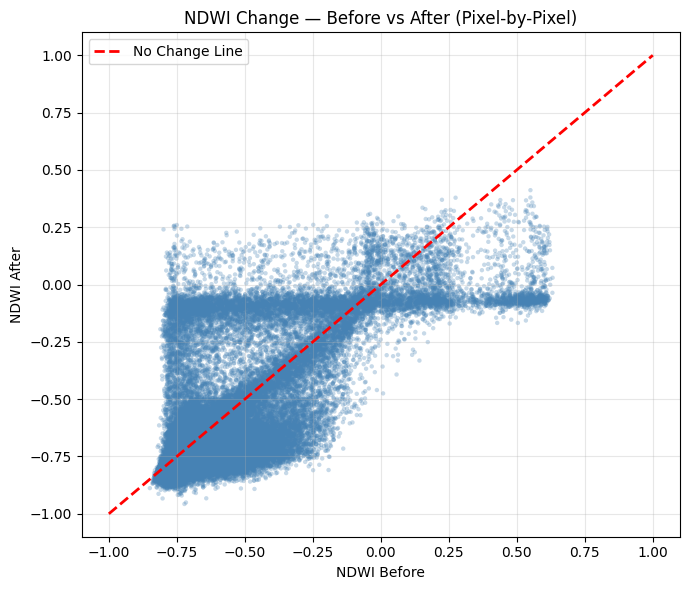

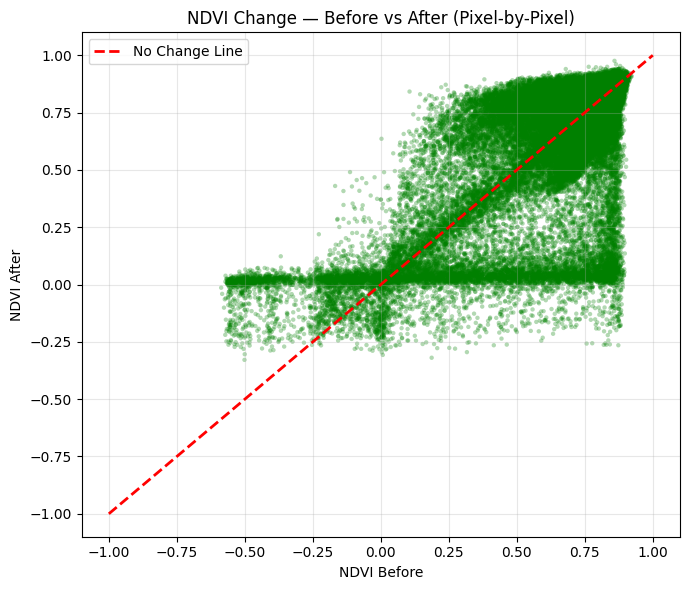

In [ ]:
for title, data in [("NDWI", (ndwi_before, ndwi_after)), ("NDVI", (ndvi_before, ndvi_after))]:
    plt.figure(figsize=(7, 4))
    plt.hist(data[0].flatten(), bins=60, alpha=0.5, label='Before')
    plt.hist(data[1].flatten(), bins=60, alpha=0.5, label='After')
    plt.title(f"{title} Distribution — Before vs After")
    plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4))
plt.bar(['New Water (km²)', 'Veg Loss (km²)'], [flood_area_km2, veg_loss_km2], color=['steelblue','darkorange'])
plt.title("Chungthang GLOF — Flood Impact Summary"); plt.ylabel("Area (km²)"); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(ndwi_before.flatten(), ndwi_after.flatten(), alpha=0.3, s=10, color='steelblue', edgecolors='none')
plt.xlabel("NDWI Before"); plt.ylabel("NDWI After")
plt.title("NDWI Change — Before vs After (Pixel-by-Pixel)")
plt.plot([-1, 1], [-1, 1], 'r--', lw=2, label='No Change Line')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(ndvi_before.flatten(), ndvi_after.flatten(), alpha=0.3, s=10, color='green', edgecolors='none')
plt.xlabel("NDVI Before"); plt.ylabel("NDVI After")
plt.title("NDVI Change — Before vs After (Pixel-by-Pixel)")
plt.plot([-1, 1], [-1, 1], 'r--', lw=2, label='No Change Line')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
def make_labels(ndvi, ndwi, ndbi):
    labels = np.full(ndvi.shape, 3, dtype=np.int8)
    labels[ndvi > 0.35]= 0
    labels[ndwi > 0.15]= 1
    labels[(ndvi < 0.10) & (ndwi < 0.05) & (ndbi < 0.20)]= 2
    return labels

labels_before = make_labels(ndvi_before, ndwi_before, ndbi_before)
labels_after  = make_labels(ndvi_after,  ndwi_after,  ndbi_after)
CLASS_NAMES = {0:"Vegetation",1:"Water",2:"Barren/Debris",3:"Built-up"}
CLASS_COLORS = ['#2ecc40','#0074d9','#b8860b','#aaaaaa']

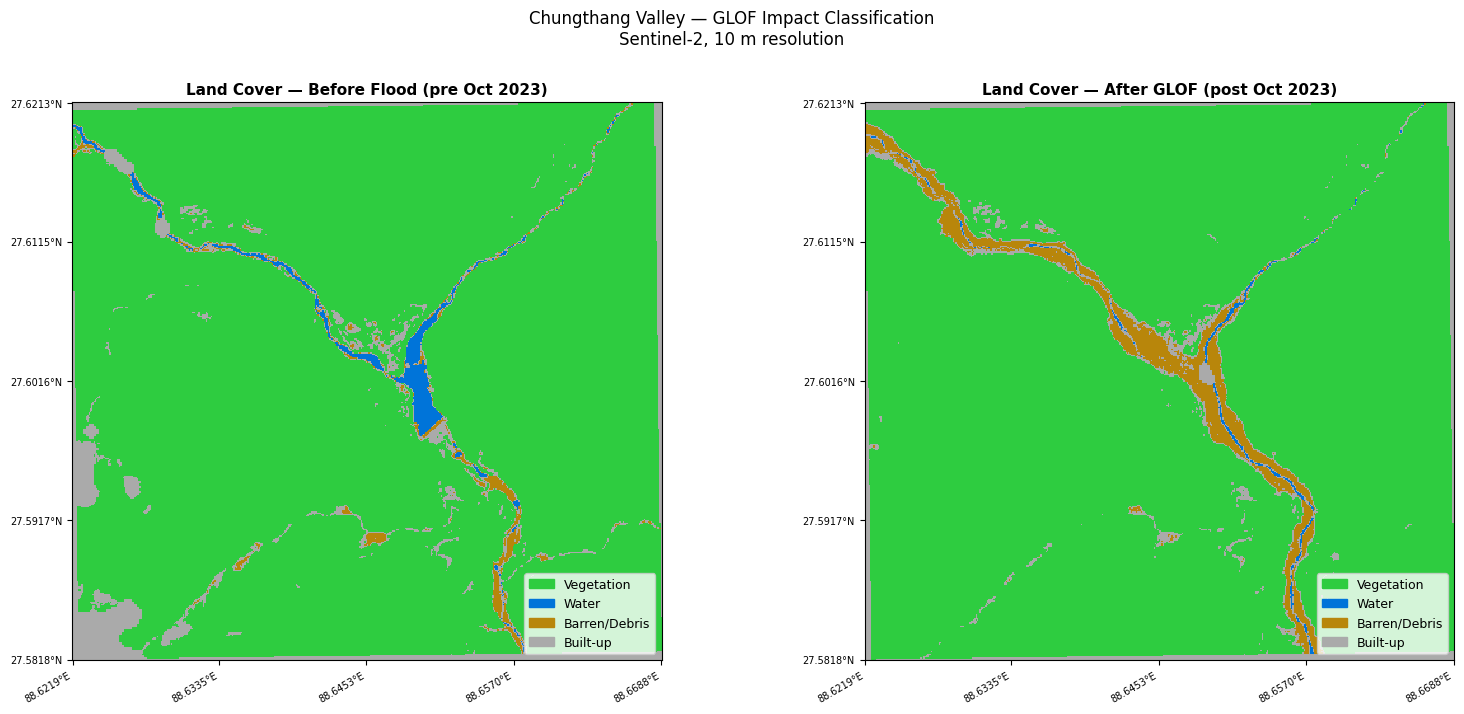

In [ ]:
lc_cmap = ListedColormap(CLASS_COLORS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, lbl, title in zip(axes,
    [labels_before, labels_after],
    ["Land Cover — Before Flood (pre Oct 2023)",
     "Land Cover — After GLOF (post Oct 2023)"]):
    ax.imshow(lbl, cmap=lc_cmap, vmin=0, vmax=3, interpolation='nearest')
    latlon_ticks(ax, before.crs, before.transform, lbl.shape)
    ax.set_title(title, fontsize=11, fontweight='bold')
    patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
               for i in range(4)]
    ax.legend(handles=patches, loc='lower right', fontsize=9)

plt.suptitle("Chungthang Valley — GLOF Impact Classification\n"
             "Sentinel-2, 10 m resolution", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


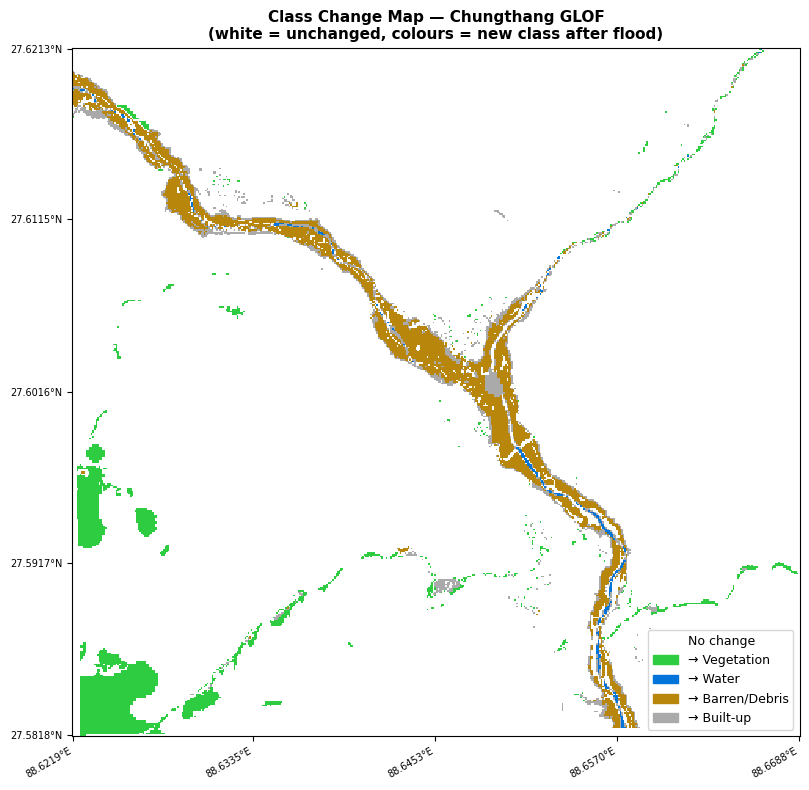

In [ ]:
nodata_before = (b2_before == 0) & (b3_before == 0) & \
                (b4_before == 0) & (b8_before == 0)
nodata_after  = (b2_after  == 0) & (b3_after  == 0) & \
                (b4_after  == 0) & (b8_after  == 0)
nodata_mask   = nodata_before | nodata_after

CHANGE_COLORS = ['white', '#2ecc40', '#0074d9', '#b8860b', '#aaaaaa']
change_cmap   = ListedColormap(CHANGE_COLORS)

diff_map = np.where(
    (labels_after != labels_before) & ~nodata_mask,
    labels_after + 1,
    0
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(diff_map, cmap=change_cmap, vmin=0, vmax=4, interpolation='nearest')
latlon_ticks(ax, after.crs, after.transform, diff_map.shape)
ax.set_title("Class Change Map — Chungthang GLOF\n"
             "(white = unchanged, colours = new class after flood)",
             fontsize=11, fontweight='bold')
change_patches = [
    mpatches.Patch(color='white',   label='No change'),
    mpatches.Patch(color='#2ecc40', label='→ Vegetation'),
    mpatches.Patch(color='#0074d9', label='→ Water'),
    mpatches.Patch(color='#b8860b', label='→ Barren/Debris'),
    mpatches.Patch(color='#aaaaaa', label='→ Built-up'),
]
ax.legend(handles=change_patches, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
class_ids  = list(CLASS_NAMES.keys())
before_km2 = [np.sum(labels_before == c) * pixel_area / 1e6 for c in class_ids]
after_km2  = [np.sum(labels_after  == c) * pixel_area / 1e6 for c in class_ids]
change_pct = [(a - b) / (b + 1e-6) * 100 for b, a in zip(before_km2, after_km2)]
print("\nClass Areas Before vs After")
print(f"{'Class':<18} {'Before (km²)':>13} {'After (km²)':>12} {'Delta km²':>10} {'Delta %':>8}")
print("─" * 66)
for i, name in CLASS_NAMES.items():
    print(f"{name:<18} {before_km2[i]:>13.2f} {after_km2[i]:>12.2f} "
          f"{after_km2[i]-before_km2[i]:>+10.2f} {change_pct[i]:>+8.1f}%")




Class Areas Before vs After
Class               Before (km²)  After (km²)  Delta km²  Delta %
──────────────────────────────────────────────────────────────────
Vegetation                 18.62        18.57      -0.05     -0.3%
Water                       0.22         0.06      -0.16    -72.0%
Barren/Debris               0.17         0.73      +0.56   +322.2%
Built-up                    1.36         1.01      -0.35    -25.8%


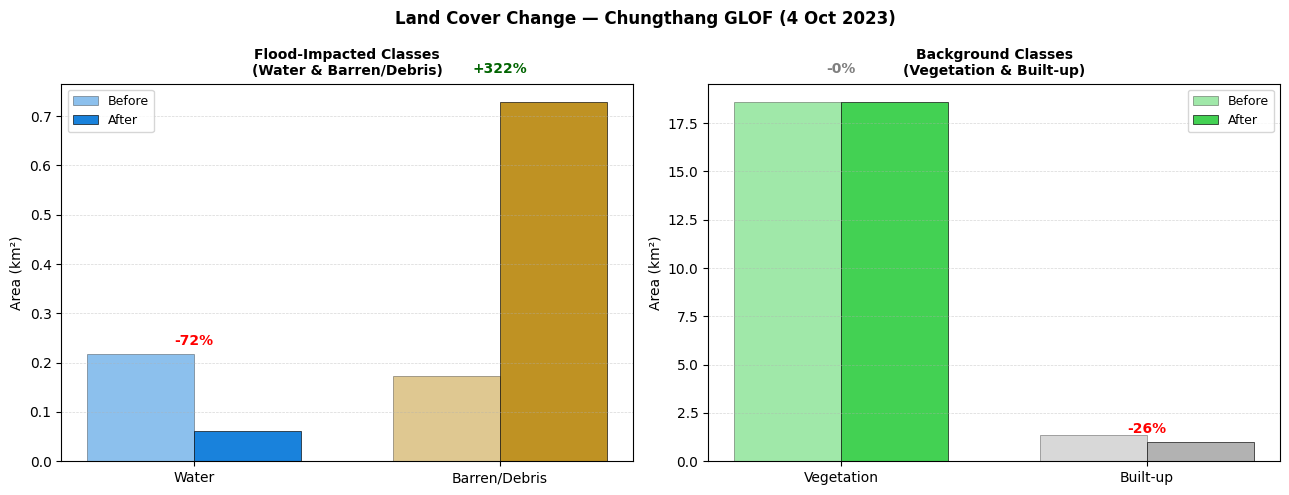

In [ ]:
x     = np.arange(len(class_ids))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
flood_classes = [1, 2]
x_f = np.arange(len(flood_classes))
for ax, cls_list, chart_title in [
    (axes[0], [1, 2], "Flood-Impacted Classes\n(Water & Barren/Debris)"),
    (axes[1], [0, 3], "Background Classes\n(Vegetation & Built-up)"),
]:
    names  = [CLASS_NAMES[c] for c in cls_list]
    colors = [CLASS_COLORS[c] for c in cls_list]
    bvals  = [before_km2[c] for c in cls_list]
    avals  = [after_km2[c]  for c in cls_list]
    pcts   = [change_pct[c] for c in cls_list]
    x_pos  = np.arange(len(cls_list))

    ax.bar(x_pos - 0.175, bvals, 0.35, label='Before',
           color=colors, alpha=0.45, edgecolor='black', linewidth=0.5)
    ax.bar(x_pos + 0.175, avals, 0.35, label='After',
           color=colors, alpha=0.9,  edgecolor='black', linewidth=0.5)

    for i, (b, a, pct) in enumerate(zip(bvals, avals, pcts)):
        col = 'red' if pct < -5 else ('darkgreen' if pct > 5 else 'gray')
        ax.text(x_pos[i], max(b, a) * 1.08, f"{pct:+.0f}%",
                ha='center', fontsize=10, fontweight='bold', color=col)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, fontsize=10)
    ax.set_ylabel("Area (km²)", fontsize=10)
    ax.set_title(chart_title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

plt.suptitle("Land Cover Change — Chungthang GLOF (4 Oct 2023)",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


Finding boundary (hard) pixels for realistic training...
  Boundary pixels : 766
  Interior pixels : 29,234

  Total training candidates : 1,540 pixels

ML Results
Train Accuracy : 87.71%
Test  Accuracy : 80.52%
Overfit gap    : 7.19%

               precision    recall  f1-score   support

   Vegetation       0.90      0.84      0.87        96
        Water       0.79      0.76      0.78        25
Barren/Debris       0.79      0.84      0.81       112
     Built-up       0.76      0.76      0.76       152

     accuracy                           0.81       385
    macro avg       0.81      0.80      0.81       385
 weighted avg       0.81      0.81      0.81       385

[[ 81   0   0  15]
 [  0  19   3   3]
 [  0   0  94  18]
 [  9   5  22 116]]


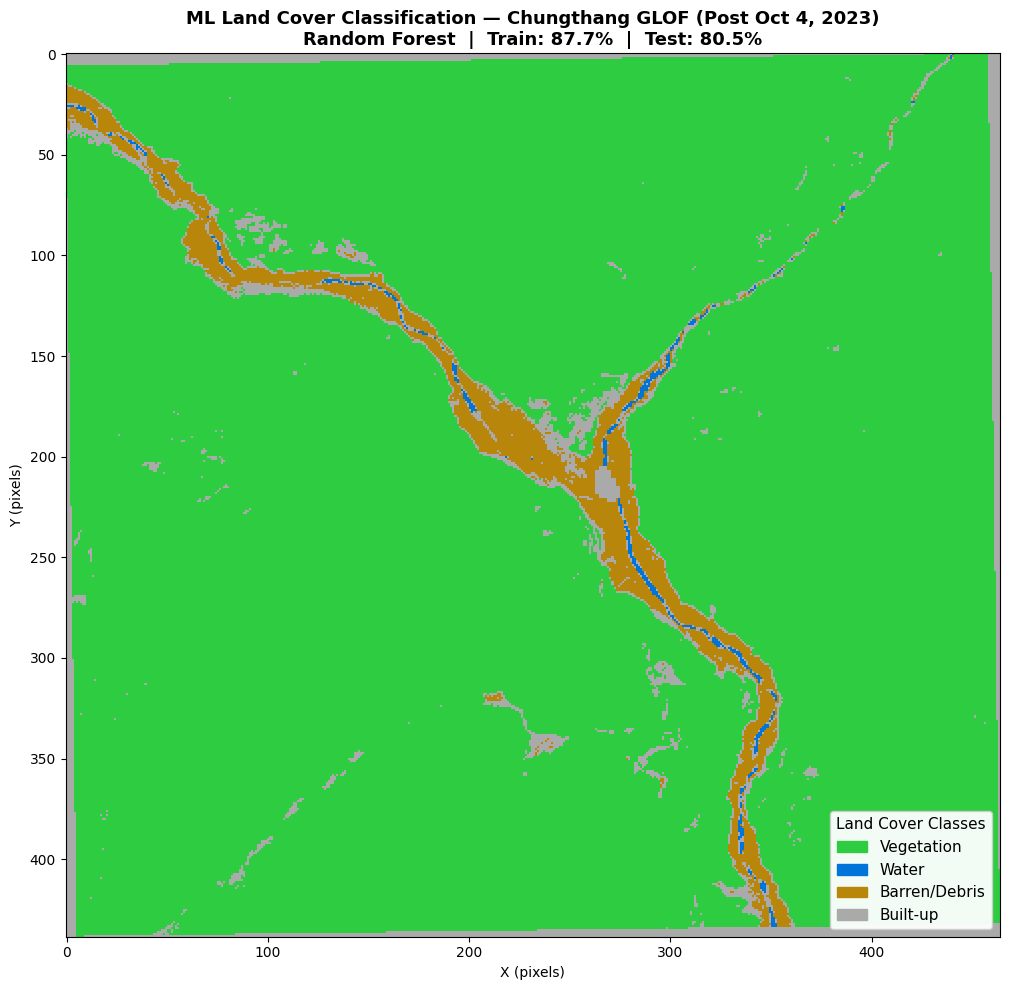

In [ ]:
features_after = np.stack([
    b2_after.astype(float),
    b3_after.astype(float),
    b4_after.astype(float),
    b8_after.astype(float),
    b11_after.astype(float) if HAS_SWIR else b8_after.astype(float)
], axis=-1)
X = features_after.reshape(-1, features_after.shape[-1])
y = labels_after.reshape(-1)
nodata = (X == 0).all(axis=1)
valid  = ~(np.isnan(X).any(axis=1) | nodata)
X = X[valid]
y = y[valid]
np.random.seed(42)
noise_std = X.std(axis=0) * 0.08
X = X + np.random.normal(0, noise_std, X.shape)
from sklearn.neighbors import KNeighborsClassifier
print("Finding boundary (hard) pixels for realistic training...")
knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
probe_size = min(30000, len(X))
probe_idx  = np.random.choice(len(X), probe_size, replace=False)
knn.fit(X[probe_idx], y[probe_idx])
neigh_labels = knn.kneighbors(X[probe_idx], return_distance=False)
neigh_classes = y[probe_idx][neigh_labels]
is_boundary = (neigh_classes != neigh_classes[:, [0]]).any(axis=1)
boundary_global_idx = probe_idx[is_boundary]
interior_global_idx = probe_idx[~is_boundary]
print(f"  Boundary pixels : {len(boundary_global_idx):,}")
print(f"  Interior pixels : {len(interior_global_idx):,}")
min_class   = min(np.sum(y == c) for c in range(4))
sample_size = min(min_class, 4000)
def stratified_sample(pool_idx, label_arr, n_per_class):
    parts = []
    for c in range(4):
        cls_pool = pool_idx[label_arr[pool_idx] == c]
        if len(cls_pool) == 0:
            continue
        n = min(n_per_class, len(cls_pool))
        parts.append(np.random.choice(cls_pool, n, replace=False))
    return np.concatenate(parts)
n_boundary = int(sample_size * 0.60)
n_interior = int(sample_size * 0.40)
idx_b = stratified_sample(boundary_global_idx, y, n_boundary)
idx_i = stratified_sample(interior_global_idx, y, n_interior)
balanced_idx = np.concatenate([idx_b, idx_i])
np.random.shuffle(balanced_idx)
X_bal = X[balanced_idx]
y_bal = y[balanced_idx]
print(f"\n  Total training candidates : {len(X_bal):,} pixels")
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.25, random_state=42, stratify=y_bal
)
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=None,
    max_features='sqrt',
    min_samples_split=20,
    min_samples_leaf=10,
    max_samples=0.7,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)
print("\nML Results")
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Test  Accuracy : {test_acc*100:.2f}%")
print(f"Overfit gap    : {(train_acc - test_acc)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_test,
      target_names=[CLASS_NAMES[i] for i in range(4)]))
print(confusion_matrix(y_test, y_pred_test))
h, w = labels_after.shape
X_full = features_after.reshape(-1, features_after.shape[-1])
X_full_noisy = X_full + np.random.normal(0, noise_std, X_full.shape)
classified_map_ml = model.predict(X_full_noisy).reshape(h, w)
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(classified_map_ml, cmap=lc_cmap, vmin=0, vmax=3, interpolation='nearest')
ax.set_title(
    f'ML Land Cover Classification — Chungthang GLOF (Post Oct 4, 2023)\n'
    f'Random Forest  |  Train: {train_acc*100:.1f}%  |  Test: {test_acc*100:.1f}%',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('X (pixels)', fontsize=10)
ax.set_ylabel('Y (pixels)', fontsize=10)
patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i]) for i in range(4)]
ax.legend(handles=patches, loc='lower right', fontsize=11,
          framealpha=0.95, title='Land Cover Classes', title_fontsize=11)
plt.tight_layout()
plt.savefig('/content/FINAL_ML_CLASSIFIED_MAP.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
ml_km2 = [np.sum(classified_map_ml == c) * pixel_area / 1e6 for c in range(4)]

print("\nML Area per Class (km²)")
for i, name in CLASS_NAMES.items():
    print(f"{name}: {ml_km2[i]:.2f}")


ML Area per Class (km²)
Vegetation: 18.50
Water: 0.06
Barren/Debris: 0.73
Built-up: 1.08


In [ ]:
for i, name in CLASS_NAMES.items():
    rule = after_km2[i]
    ml   = ml_km2[i]
    diff = ml - rule
    pct  = (diff / (rule + 1e-6)) * 100

    print(f"{name}: Rule={rule:.2f}, ML={ml:.2f}, Diff={diff:+.2f}, {pct:+.1f}%")

Vegetation: Rule=18.57, ML=18.50, Diff=-0.07, -0.4%
Water: Rule=0.06, ML=0.06, Diff=+0.00, +1.3%
Barren/Debris: Rule=0.73, ML=0.73, Diff=+0.00, +0.2%
Built-up: Rule=1.01, ML=1.08, Diff=+0.07, +6.8%
